<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/ESAA_WEEK11_2_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8.3 하이퍼파라미터를 이용한 성능 최적화

## 8.3.1 배치 정규화를 이용한 성능 최적화

### 정규화

- 데이터 범위를 사용자가 원하는 범위로 제한하는 것

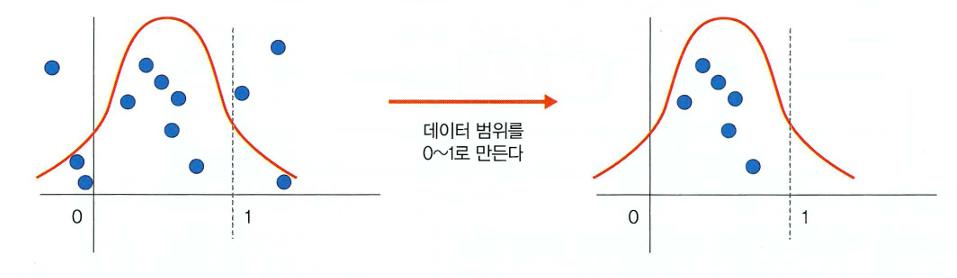

- MinMaxScaler() 기법 사용

### 규제화

- 모델 복잡도를 줄이기 위해 제약을 두는 방법
  - 제약 : 네트워크에 들어가기 전 필터를 적용한 것
- 방법
  - 드롭아웃
  - 조기 종료

### 표준화

- 기존 데이터를 평균은 0, 표준편차는 1인 형태의 데이터로 만드는 방법

### 배치 정규화

- 기울기 소멸, 기울기 폭발 문제를 해결하기 위한 방법
  - 기울기 소멸 : 오차 정보를 역전파시키는 과정에서 기울기가 급격히 0에 가까워져 학습이 안되는 현상
  - 기울기 폭발 : 학습 과정에서 기울기가 급격히 커지는 현상
- 손실함수로 렐루를 사용하거나, 초깃값 튜닝, 학습률 조정

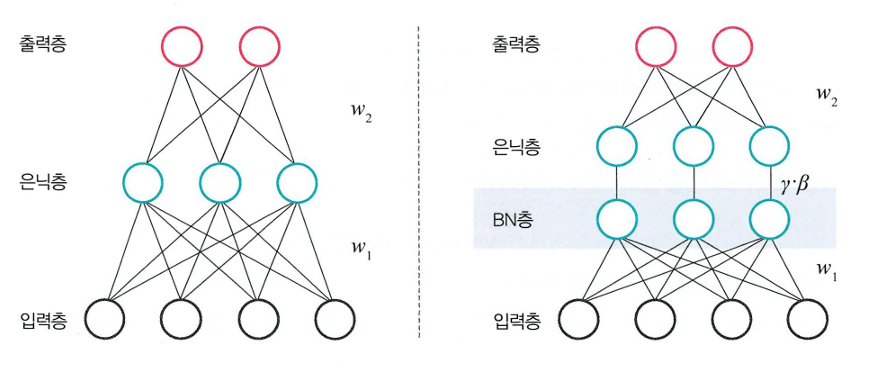

- 기울기 폭발과 소멸의 원인 = 내부 공변량 변화
  - 각 층마다 활성화 함수가 적용되며 입력 값들의 분포가 계속 바뀌는 현상을 의미
- 신경망 학습 중에 각 층으로 들어가는 값들의 분포가 너무 들쭉날쭉하지 않도록, 미니배치 단위로 평균을 0, 표준편차를 1에 가깝게 맞춰주는 과정
  - 신경망을 학습하다 보면 각 층에 들어가는 값들의 분포가 계속 변하고 퍼질 수 있음
  - 그래서 미니배치 단위로 평균과 표준편차를 계산한 뒤, 각 값을 평균 0, 표준편차 1이 되도록 조정
  - 이렇게 하면 입력값의 스케일이 안정되어 학습이 더 잘 진행됨

## 8.3.2 드롭아웃을 이용한 성능 최적화

- 과적합 : 훈련 데이터셋을 과하게 학습하는 것을 의미
- 드롭아웃
  - 훈련 시, 일정 비율의 뉴런만 사용하고 나머지 뉴런에 해당하는 가중치는 업데이트하지 않음
  - 매 단계마다 사용하지 않는 뉴런을 바꿔가며 훈련
  - 은닉층에 배치된 노드 중 일부를 임의로 끄며 학습

In [1]:
# 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [2]:
# 8-2 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(
    root='../chap08/data/',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.53MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 135kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.50MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.39MB/s]


In [4]:
# 8-3 데이터셋을 메모리로 가져오기
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

In [5]:
# 8-4 데이터셋 분리
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
1


In [7]:
# 8-5 이미지 데이터를 출력하기 위한 전처리
def imshow(img, title):
    plt.figure(figsize=(batch_size * 4, 4))  # 출력할 개별 이미지의 크기 지정
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0)))  # (채널, 높이, 너비) -> (높이, 너비, 채널)
    plt.title(title)
    plt.show()

In [8]:
# 8-6 이미지 데이터 출력 함수
def show_batch_images(dataloader):
    images, labels = next(iter(dataloader))

    img = torchvision.utils.make_grid(images)
    imshow(img, title=[str(x.item()) for x in labels])

    return images, labels

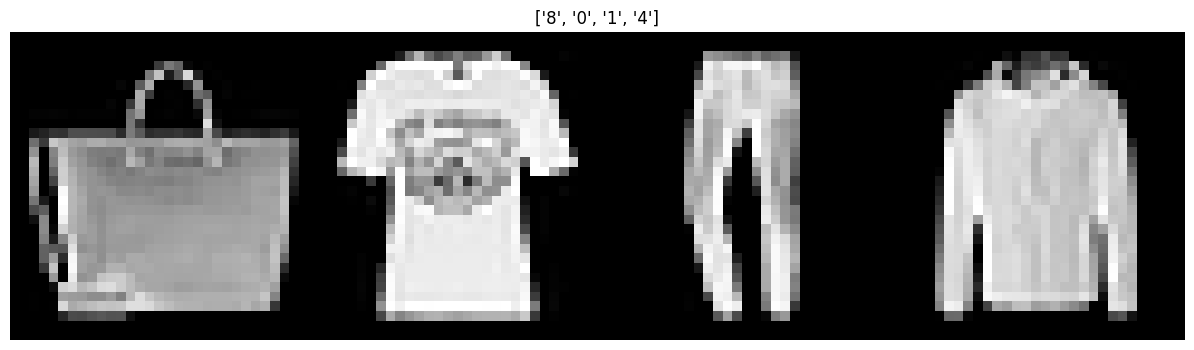

In [9]:
# 8=7 이미지 출력
images, labels = show_batch_images(trainloader)

In [10]:
# 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(784, 48),  # 28x28 크기의 이미지를 입력으로 받음
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, 10)    # FashionMNIST 클래스는 총 10개
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [13]:
# 8-9 배치 정규화가 적용된 네트워크
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.BatchNorm1d(48),  # 배치 정규화는 완전언결층과 합성곱층 뒤, 활성화 함수 앞에 위치
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [14]:
# 8-10 배치 정규화가 적용되지 않은 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [15]:
# 8-11 배치 정규화가 적용된 모델 선언
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [16]:
# 8-12 데이터셋 메모리로 불러오기
batch_size = 512

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True
)

In [17]:
# 8-13 옵티마이저 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()

opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

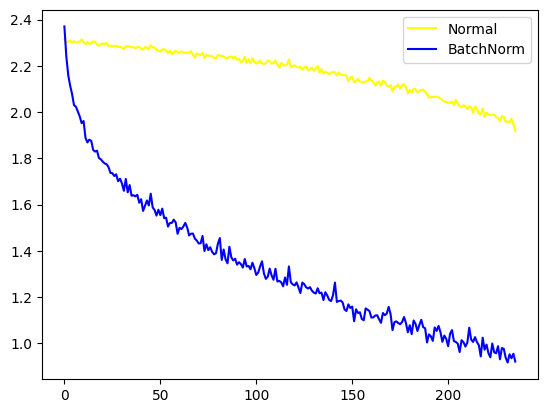

In [18]:
# 8-14 모델학습
loss_arr = []
loss_bn_arr = []

max_epochs = 2

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        # 배치 정규화가 적용되지 않은 모델의 학습
        opt.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        # 배치 정규화가 적용된 모델의 학습
        opt_bn.zero_grad()
        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

plt.plot(loss_arr, 'yellow', label='Normal')
plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
plt.legend()
plt.show()

In [19]:
# 8-15 데이터셋의 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)  # 주어진 범위에서 균등한 값을 갖는 텐서를 만들기 위해 사용
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

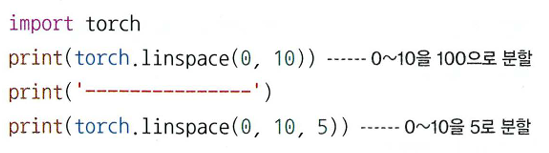

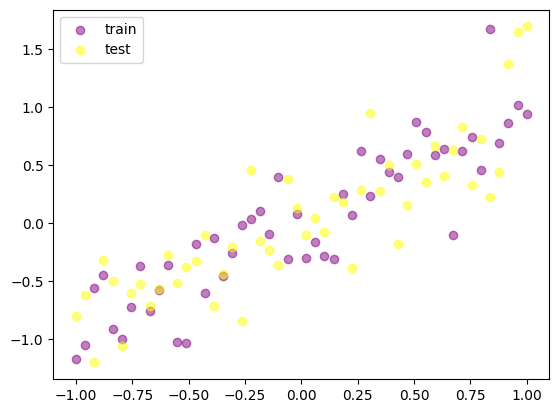

In [20]:
# 8-16 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
            alpha=0.5, label='train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
            alpha=0.5, label='test')

plt.legend()
plt.show()

In [21]:
# 8-17 드롭이웃을 위한 모델 생성
N_h = 100

model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)  # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),  # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
)  # 드롭아웃이 적용된 모델

In [22]:
# 8-18 옵티마이저와 손실 함수 지정
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)

loss_fn = torch.nn.MSELoss()

/tmp/ipykernel_10586/1111015964.py:65: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  'Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f'


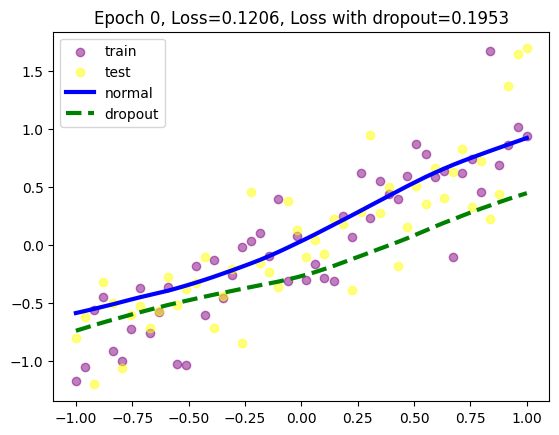

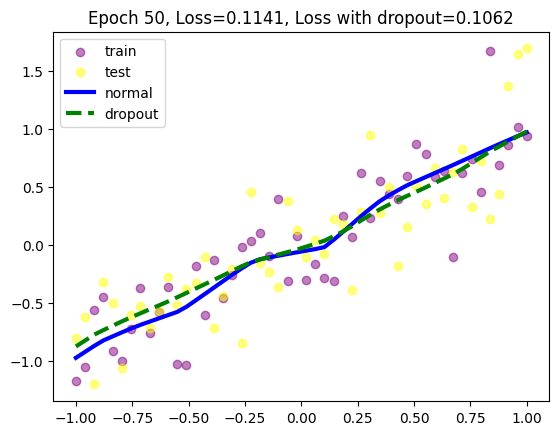

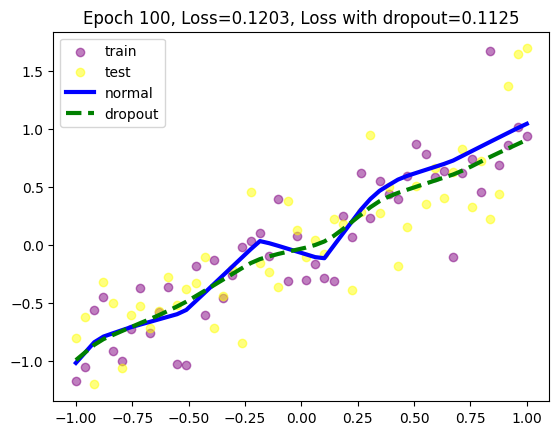

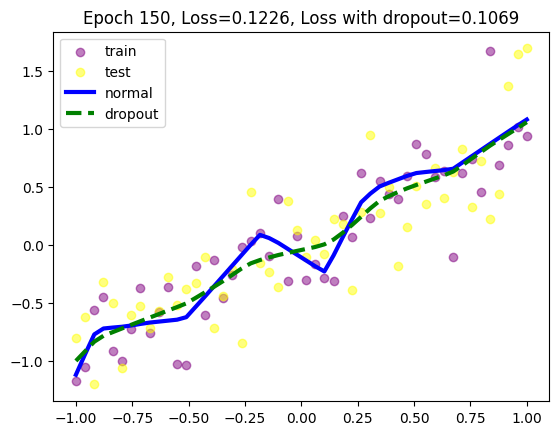

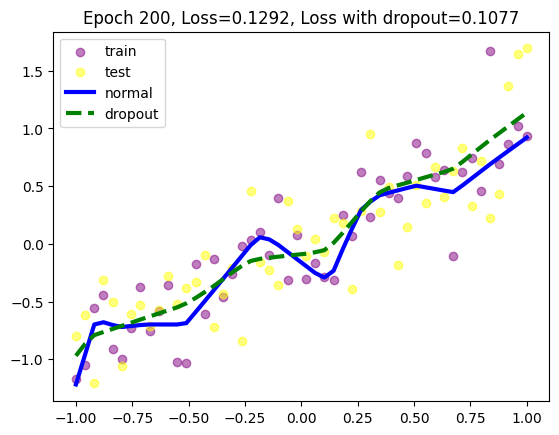

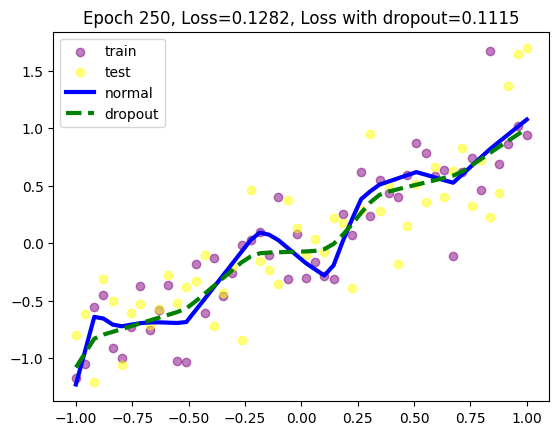

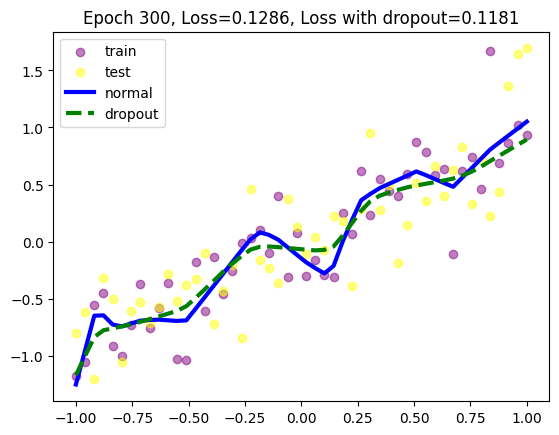

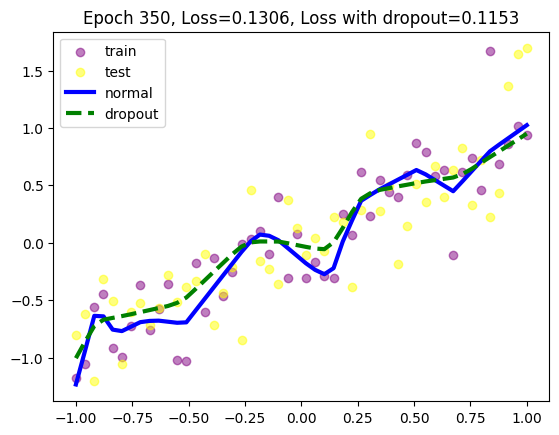

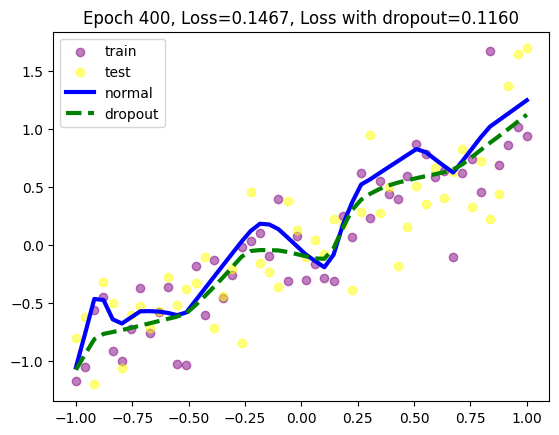

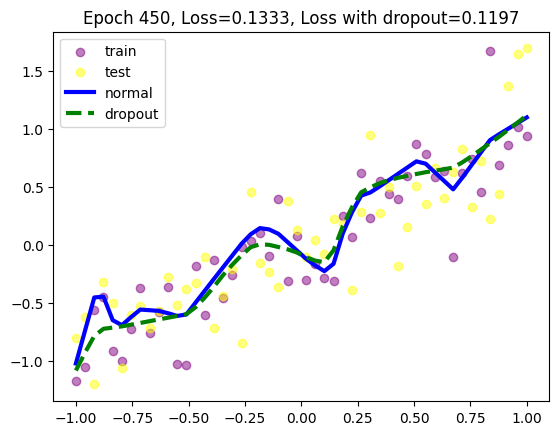

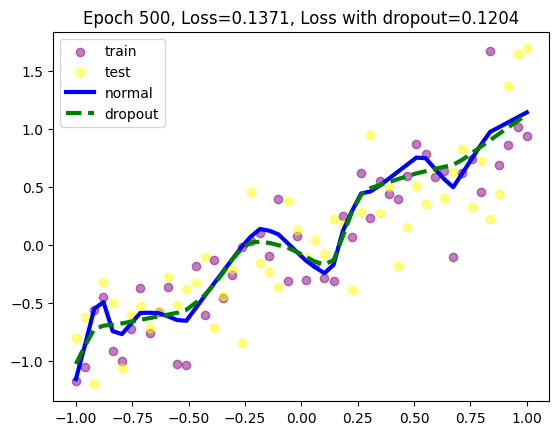

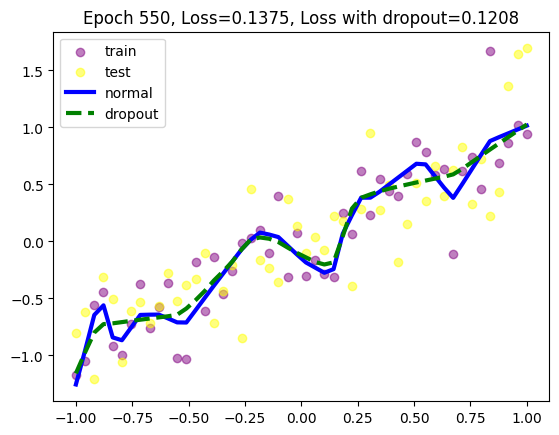

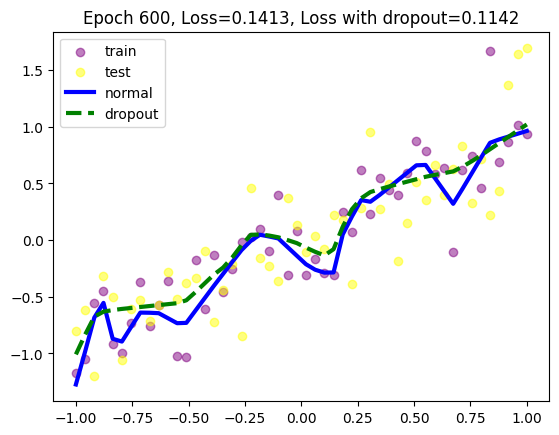

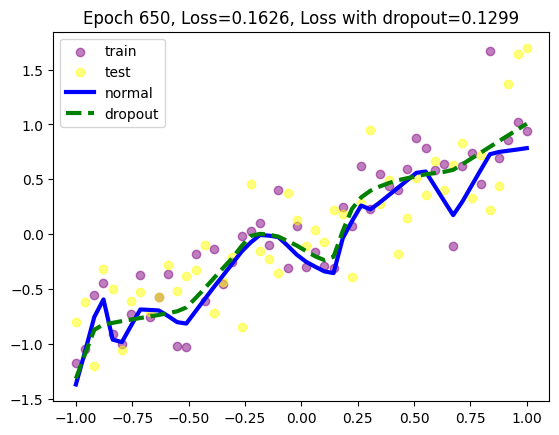

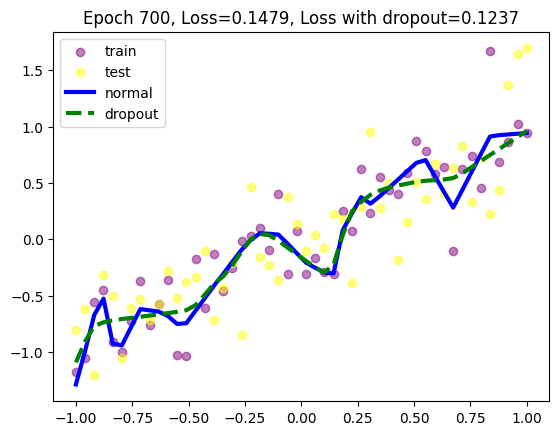

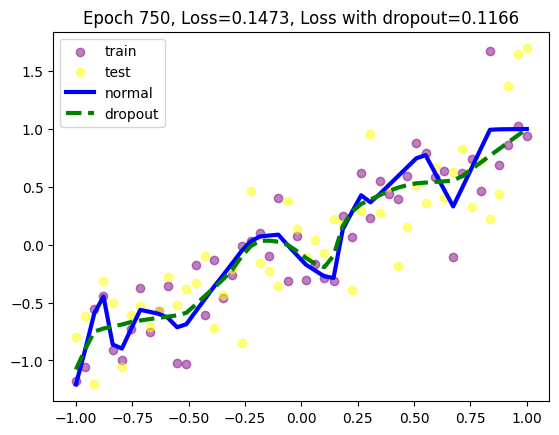

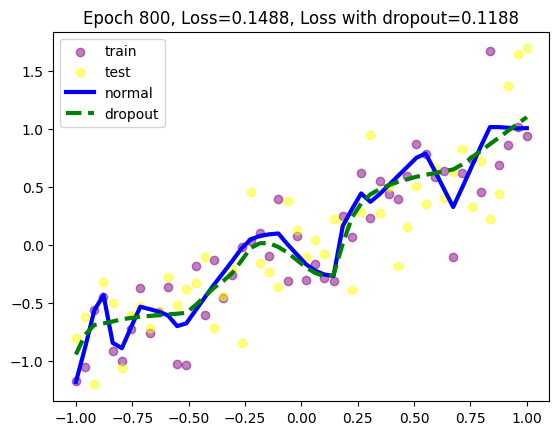

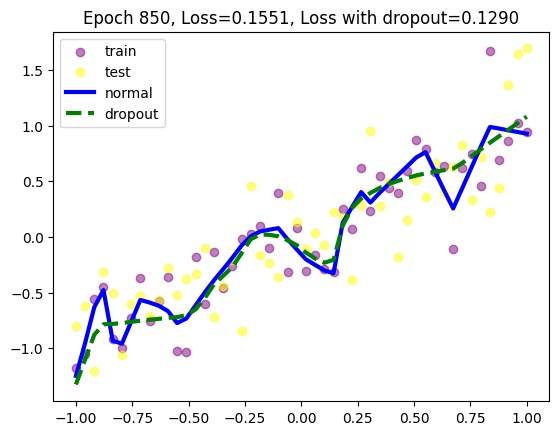

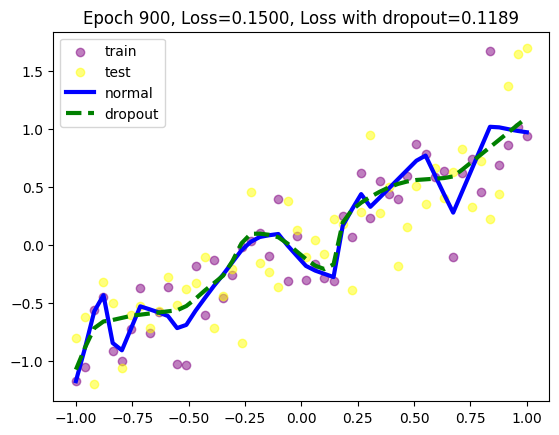

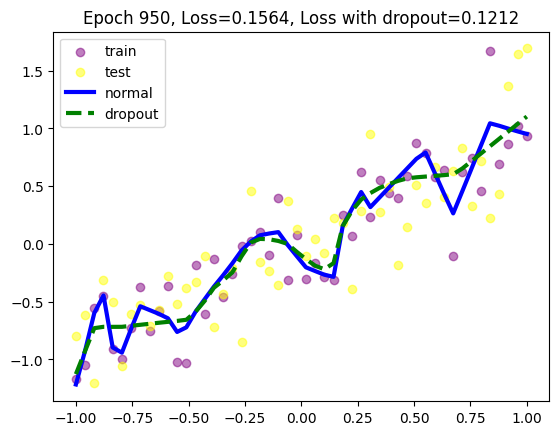

In [23]:
# 8-19 모델학습
max_epochs = 1000

for epoch in range(max_epochs):
    # 드롭아웃이 적용되지 않은 모델 학습
    pred = model(x_train)
    loss = loss_fn(pred, y_train)

    opt.zero_grad()
    loss.backward()
    opt.step()

    # 드롭아웃이 적용된 모델 학습
    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)

    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    # epoch를 50으로 나눈 나머지가 0이면 진행
    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(
            x_train.data.numpy(),
            y_train.data.numpy(),
            c='purple',
            alpha=0.5,
            label='train'
        )

        plt.scatter(
            x_test.data.numpy(),
            y_test.data.numpy(),
            c='yellow',
            alpha=0.5,
            label='test'
        )

        plt.plot(
            x_test.data.numpy(),
            test_pred.data.numpy(),
            'b-',
            lw=3,
            label='normal'
        )

        plt.plot(
            x_test.data.numpy(),
            test_pred_dropout.data.numpy(),
            'g--',
            lw=3,
            label='dropout'
        )

        plt.title(
            'Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f'
            % (epoch, test_loss, test_loss_dropout)
        )

        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)

- 훈련 횟수가 늘어날수록 파란색 실선은 가장자리의 자주색 점들을 찾아가고 있음
- 자주색 점들은 훈련 데이터셋이기에 어떻게 보면 과적합 현상이 나타나고 있는 것으로도 보임

## 8.3.3 조기 종료를 이용한 성능 최적화

- 조기 종료 : 뉴럴 네트워크가 과적합을 회피하는 규제 기법
  - 훈련 데이터와 별도로 검증 데이터를 준비
  - 매 에포크마다 검증 데이터에 대한 오차를 측정하여 모델의 종료 시점 제어
  - 즉, 과적합 발생 전까지 학습에 대한 오차와 검증에 대한 오차 모두 감소하지만, 과적합이 발생하면 훈련 데이터셋에 대한 오차는 감소하는 반면 검증 데이터셋에 대한 오차는 증가함
  - 조기 종료는 검증 데이터셋에 대한 오차가 증가하는 시점에서 학습을 멈추도록 조정


In [24]:
# 8-20 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models  # 사전 학습된 모델을 이용하고자 할 때 사용하는 라이브러리
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm

matplotlib.style.use('ggplot')  # 출력 그래프에서 격자로 숫자 범위가 눈에 잘 띄도록 하는 스타일

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [25]:
# 8-21 데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
# 8-22 데이터셋 가져오기
!git clone https://github.com/gilbutITbook/080289.git
train_path = './080289/chap08/data/archive/train'
test_path = './080289/chap08/data/archive/test'

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_dataset = datasets.ImageFolder(
    root=test_path,
    transform=val_transform
)

val_dataloader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 25.34 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [31]:
# 8-23 모델생성
def resnet50(pretrained=True, requires_grad=False):
    model = models.resnet50(progress=True, pretrained=pretrained)

    if requires_grad == False:  # 파라미터를 고정하여 backward() 중에 기울기가 계산되지 않도록 함
        for param in model.parameters():
            param.requires_grad = False

    elif requires_grad == True:  # 파라미터 값이 backward() 중에 기울기 계산에 반영됨
        for param in model.parameters():
            param.requires_grad = True

    model.fc = nn.Linear(2048, 2)

    return model

In [32]:
# 8-24 학습률 감소
class LRScheduler():
  def __init__(
      self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode = 'min',
          patience = self.patience,
          factor = self.factor,
          min_lr = self.min_lr,
          verbose = True
      )

  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss)

In [33]:
# 8-25 조기 종료
class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '/content/080289/chap08/data/checkpoint.pt'):
    self.patience = patience
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.Inf
    self.delta = delta
    self.path = path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

In [34]:
# 8-26 인수 값 지정
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true')
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true')
args, unknown = parser.parse_known_args()
args = vars(args)

In [35]:
# 8-27 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Computation device: cpu



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.3MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


In [36]:
# 8-28 옵티마이저와 손실 함수 지정
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

In [37]:
# 8-29 오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

In [38]:
# 8-30 오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plt_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

In [39]:
# 8-31 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size))
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

In [40]:
# 8-32 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size))
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

In [ ]:
# 8-33 모델 학습
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [05:56, 22.29s/it]


Validating


16it [01:36,  6.05s/it]


Train Loss: 2.1196, Train Acc: 60.84
Val Loss: 87.0599, Val Acc: 10.20
Training time: 7.560 minutes
Epoch 2 of 100
Training


...

16it [05:59, 22.44s/it]


Validating


16it [01:36,  6.06s/it]


Train Loss: 0.1716, Train Acc: 93.17
Val Loss: 0.8391, Val Acc: 71.60
Training time: 174.833 minutes
Epoch 24 of 100
Training


 40%|████      | 6/15 [02:18<03:27, 23.08s/it]

In [ ]:
# 8-34 모델 학습 결과 출력
print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy')
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss')
plt.plot(val_loss, color = 'red', label = 'validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'/content/080289/chap08/data/{model_name}.pt')
print('TRAINING COMPLETE')